In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    brier_score_loss
)

In [3]:
df = pd.read_csv("bank-full.csv", sep=';')

le = LabelEncoder()
y = le.fit_transform(df["y"])
X = df.drop(columns=["y"])

In [4]:
# Split stratifié : 70% train / 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
for train_idx, temp_idx in sss1.split(X, y):
    X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
    y_train, y_temp = y[train_idx], y[temp_idx]

# Split stratifié : 50% val / 50% test sur le temp (=> 15/15 global)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
for val_idx, test_idx in sss2.split(X_temp, y_temp):
    X_val,  X_test  = X_temp.iloc[val_idx],  X_temp.iloc[test_idx]
    y_val,  y_test  = y_temp[val_idx],        y_temp[test_idx]

print(f"Train : {len(X_train):>6}  ({y_train.mean():.1%} positifs)")
print(f"Val   : {len(X_val):>6}  ({y_val.mean():.1%} positifs)")
print(f"Test  : {len(X_test):>6}  ({y_test.mean():.1%} positifs)")

Train :  31647  (11.7% positifs)
Val   :   6782  (11.7% positifs)
Test  :   6782  (11.7% positifs)


In [5]:
categorical_nominal = ["job", "marital", "education", "contact", "month", "poutcome"]
categorical_binary  = ["default", "housing", "loan"]
numerical_features  = ["age", "balance", "day", "campaign", "pdays", "previous"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num",     StandardScaler(),                                    numerical_features),
        ("cat_nom", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_nominal),
        ("cat_bin", OneHotEncoder(drop="if_binary"),                     categorical_binary)
    ]
)

preprocessor.fit(X_train)

print(f"Features : {len(preprocessor.get_feature_names_out())}")

Features : 41


In [6]:
# Transform
X_train_final = preprocessor.transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)

In [10]:
def evaluate_probas(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "roc_auc":   roc_auc_score(y_true, y_proba),
        "pr_auc":    average_precision_score(y_true, y_proba),
        "brier":     brier_score_loss(y_true, y_proba),
        "f1":        f1_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "threshold": threshold,
    }

In [12]:
logreg = LogisticRegression(
    max_iter=500,              # nombre max d’itérations pour converger
    class_weight="balanced",   # gère le déséquilibre
    solver="lbfgs"             # algorithme d’optimisation standard
)

logreg.fit(X_train_final, y_train)

proba_train = logreg.predict_proba(X_train_final)[:, 1]
proba_val   = logreg.predict_proba(X_val_final)[:, 1]
proba_test  = logreg.predict_proba(X_test_final)[:, 1]

results = pd.DataFrame([
    {"split": "train", **evaluate_probas(y_train, proba_train, 0.5)},
    {"split": "val",   **evaluate_probas(y_val,   proba_val,   0.5)},
    {"split": "test",  **evaluate_probas(y_test,  proba_test,  0.5)},
])

results

,split,roc_auc,pr_auc,brier,f1,recall,precision,threshold
0,train,0.768313,0.397489,0.184473,0.375426,0.625608,0.268180,0.5
1,val,0.771820,0.416180,0.183913,0.375000,0.627204,0.267454,0.5
2,test,0.768115,0.414500,0.182322,0.373253,0.622951,0.266451,0.5


In [31]:
#J'utilise le résultat déjà trouvé avant que C=0.1 soit le meilleur hyperparamètre pour la régularisation de la régression logistique. Je réentraîne donc un modèle avec ce paramètre et j'évalue à nouveau les performances sur l'ensemble de validation.
best_logreg = LogisticRegression(max_iter=500, class_weight="balanced", solver="lbfgs", C=0.1)
best_logreg.fit(X_train_final, y_train)

proba_val_tuned = best_logreg.predict_proba(X_val_final)[:, 1]
print(evaluate_probas(y_val, proba_val_tuned, threshold=0.5))

{'roc_auc': np.float64(0.7721887940448486), 'pr_auc': np.float64(0.415556113626157), 'brier': np.float64(0.1845520378165693), 'f1': 0.3759342301943199, 'recall': 0.6335012594458438, 'precision': 0.26726886291179597, 'threshold': 0.5}


In [32]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
import matplotlib.pyplot as plt

calibrated_logreg_iso = CalibratedClassifierCV(best_logreg, method='isotonic', cv='prefit')
calibrated_logreg_iso.fit(X_val_final, y_val)
proba_val_calibrated_iso = calibrated_logreg_iso.predict_proba(X_val_final)[:, 1]

# Je n'affiche pas les courbes etc, ici c'est surtout intermédiaire

c:\Users\Maxime\anaconda3\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


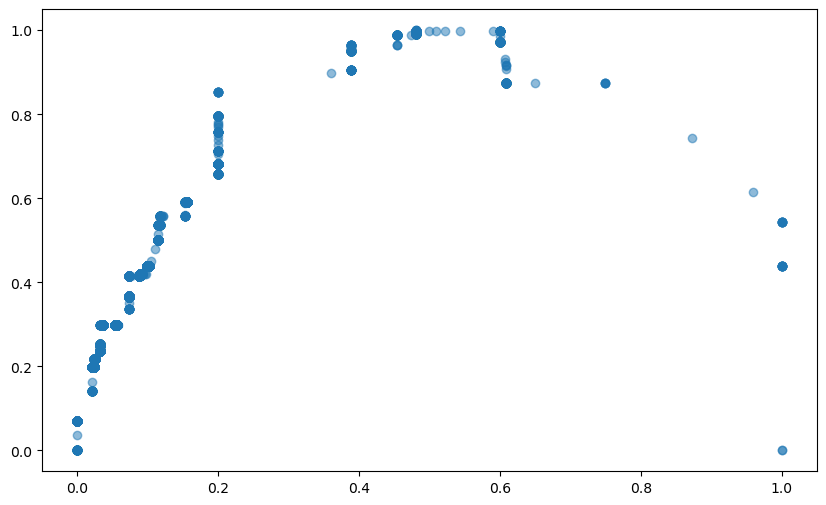

In [38]:
p = calibrated_logreg_iso.predict_proba(X_test_final)[:, 1]
p = np.clip(p, 1e-10, 1 - 1e-10)  # évite log2(0)
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
plt.figure(figsize=(10, 6))
plt.scatter(proba_test, entropy, alpha=0.5)

100%|===================| 6766/6782 [00:40<00:00]        

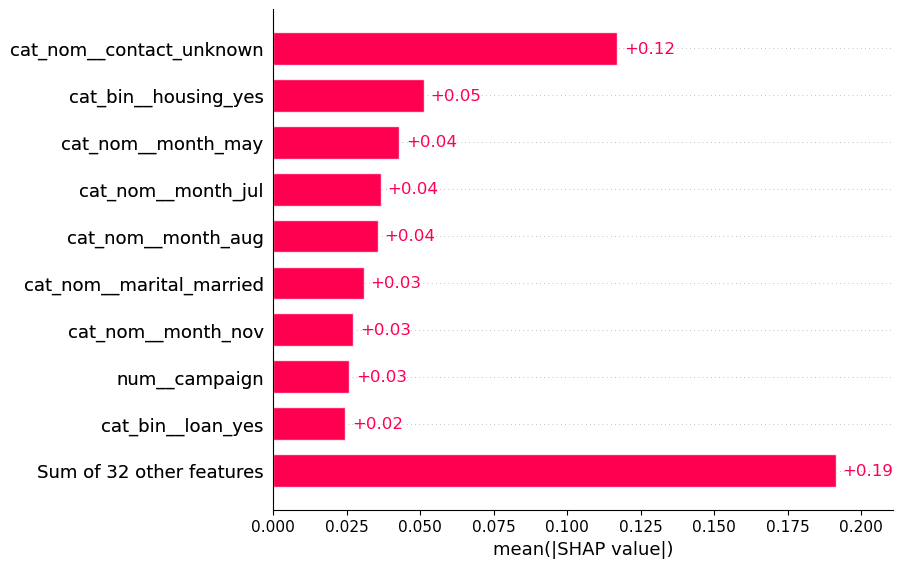

In [45]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_dense, columns=feature_names)

xgb_entropy = xgb.XGBRegressor(n_estimators=300, max_depth=4, random_state=42)
xgb_entropy.fit(X_test_df, entropy)

explainer = shap.Explainer(xgb_entropy, X_test_df)
shap_values = explainer(X_test_df)

shap.plots.bar(shap_values)
